# Eixo 4 - Segmentacao de Clientes (Analise Nao Supervisionada)

## Contexto e objetivo

A base contem aproximadamente 9.000 clientes ativos de cartao de credito e resume 6 meses de comportamento financeiro.

Objetivo: segmentar clientes para orientar estrategia de marketing com grupos comparaveis e acionaveis.

## Decisao de negocio

Neste notebook adotamos **3 clusters** como decisao final de negocio, priorizando acionabilidade de marketing sem perder consistencia tecnica.

In [1]:
# Configuracoes e bibliotecas
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    calinski_harabasz_score,
    davies_bouldin_score,
)
from sklearn.manifold import TSNE

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
K_FINAL = 3

In [2]:
# Carregamento da base
DATA_PATH = "eixo4_database.csv"
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

print(f"Dimensao: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()

Dimensao: 8950 linhas x 18 colunas


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## 1) Qualidade de dados e entendimento inicial

In [3]:
# Informacoes gerais
print("Tipos de dados:")
print(df.dtypes)
print()
print(f"Duplicatas: {df.duplicated().sum()}")
print(f"Clientes unicos (CUST_ID): {df['CUST_ID'].nunique()}")

Tipos de dados:
CUST_ID                                 str
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

Duplicatas: 0
Clientes unicos (CUST_ID): 8950


In [4]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

quality_table = pd.DataFrame({
    "missing_values": missing,
    "missing_pct": missing_pct,
    "dtype": df.dtypes.astype(str),
}).sort_values("missing_values", ascending=False)

quality_table

,missing_values,missing_pct,dtype
MINIMUM_PAYMENTS,313,3.50,float64
CREDIT_LIMIT,1,0.01,float64
BALANCE_FREQUENCY,0,0.00,float64
BALANCE,0,0.00,float64
CASH_ADVANCE_FREQUENCY,0,0.00,float64
CASH_ADVANCE,0,0.00,float64
CASH_ADVANCE_TRX,0,0.00,int64
CUST_ID,0,0.00,str
INSTALLMENTS_PURCHASES,0,0.00,float64
ONEOFF_PURCHASES,0,0.00,float64


In [5]:
# Estatisticas descritivas
pd.set_option("display.max_columns", 40)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [6]:
# Dicionario de dados resumido
data_dictionary = pd.DataFrame([
    ("CUST_ID", "Identificador unico do cliente"),
    ("BALANCE", "Saldo em conta"),
    ("BALANCE_FREQUENCY", "Frequencia de atualizacao do saldo (0-1)"),
    ("PURCHASES", "Valor total de compras"),
    ("ONEOFF_PURCHASES", "Compras em valor unico"),
    ("INSTALLMENTS_PURCHASES", "Compras parceladas"),
    ("CASH_ADVANCE", "Valor de cash advance"),
    ("PURCHASES_FREQUENCY", "Frequencia de compras (0-1)"),
    ("ONEOFF_PURCHASES_FREQUENCY", "Frequencia de compras em valor unico"),
    ("PURCHASES_INSTALLMENTS_FREQUENCY", "Frequencia de compras parceladas"),
    ("CASH_ADVANCE_FREQUENCY", "Frequencia de cash advance"),
    ("CASH_ADVANCE_TRX", "Transacoes de cash advance"),
    ("PURCHASES_TRX", "Transacoes de compra"),
    ("CREDIT_LIMIT", "Limite de credito"),
    ("PAYMENTS", "Valor pago"),
    ("MINIMUM_PAYMENTS", "Pagamento minimo"),
    ("PRC_FULL_PAYMENT", "Percentual de pagamento total"),
    ("TENURE", "Tempo de relacionamento"),
], columns=["variavel", "descricao"])

data_dictionary

,variavel,descricao
0,CUST_ID,Identificador unico do cliente
1,BALANCE,Saldo em conta
2,BALANCE_FREQUENCY,Frequencia de atualizacao do saldo (0-1)
3,PURCHASES,Valor total de compras
4,ONEOFF_PURCHASES,Compras em valor unico
5,INSTALLMENTS_PURCHASES,Compras parceladas
6,CASH_ADVANCE,Valor de cash advance
7,PURCHASES_FREQUENCY,Frequencia de compras (0-1)
8,ONEOFF_PURCHASES_FREQUENCY,Frequencia de compras em valor unico
9,PURCHASES_INSTALLMENTS_FREQUENCY,Frequencia de compras parceladas


## 2) Analise exploratoria

Como tem algumas colunas com redundancia, vou jogar fora. As colunas são:
- Cust_id
- PURCHASES e PURCHASES_FREQUENCY (porque é a soma das colunas ONEOFF_PURCHASES e INSTALLMENTS_PURCHASE)
- CASH_ADVANCE_FREQUENCY (pois vamos normalizar tudo depois e ele mede a mesma coisa que o CASH_ADVANCE)
- PURCHASES_INSTALLMENTS_FREQUENCY
- ONEOFF_PURCHASES_FREQUENCY


In [7]:
df = df.drop( columns = [ 'PURCHASES', 'BALANCE_FREQUENCY',
                          'PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 
                          'CUST_ID', 'ONEOFF_PURCHASES_FREQUENCY', 
                          'PURCHASES_INSTALLMENTS_FREQUENCY' ] )

In [8]:
# Definicao das features numericas
id_col = "CUST_ID"
features = [c for c in df.columns if c != id_col]

print(f"Quantidade de features de modelagem: {len(features)}")
print(features)

Quantidade de features de modelagem: 11
['BALANCE', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


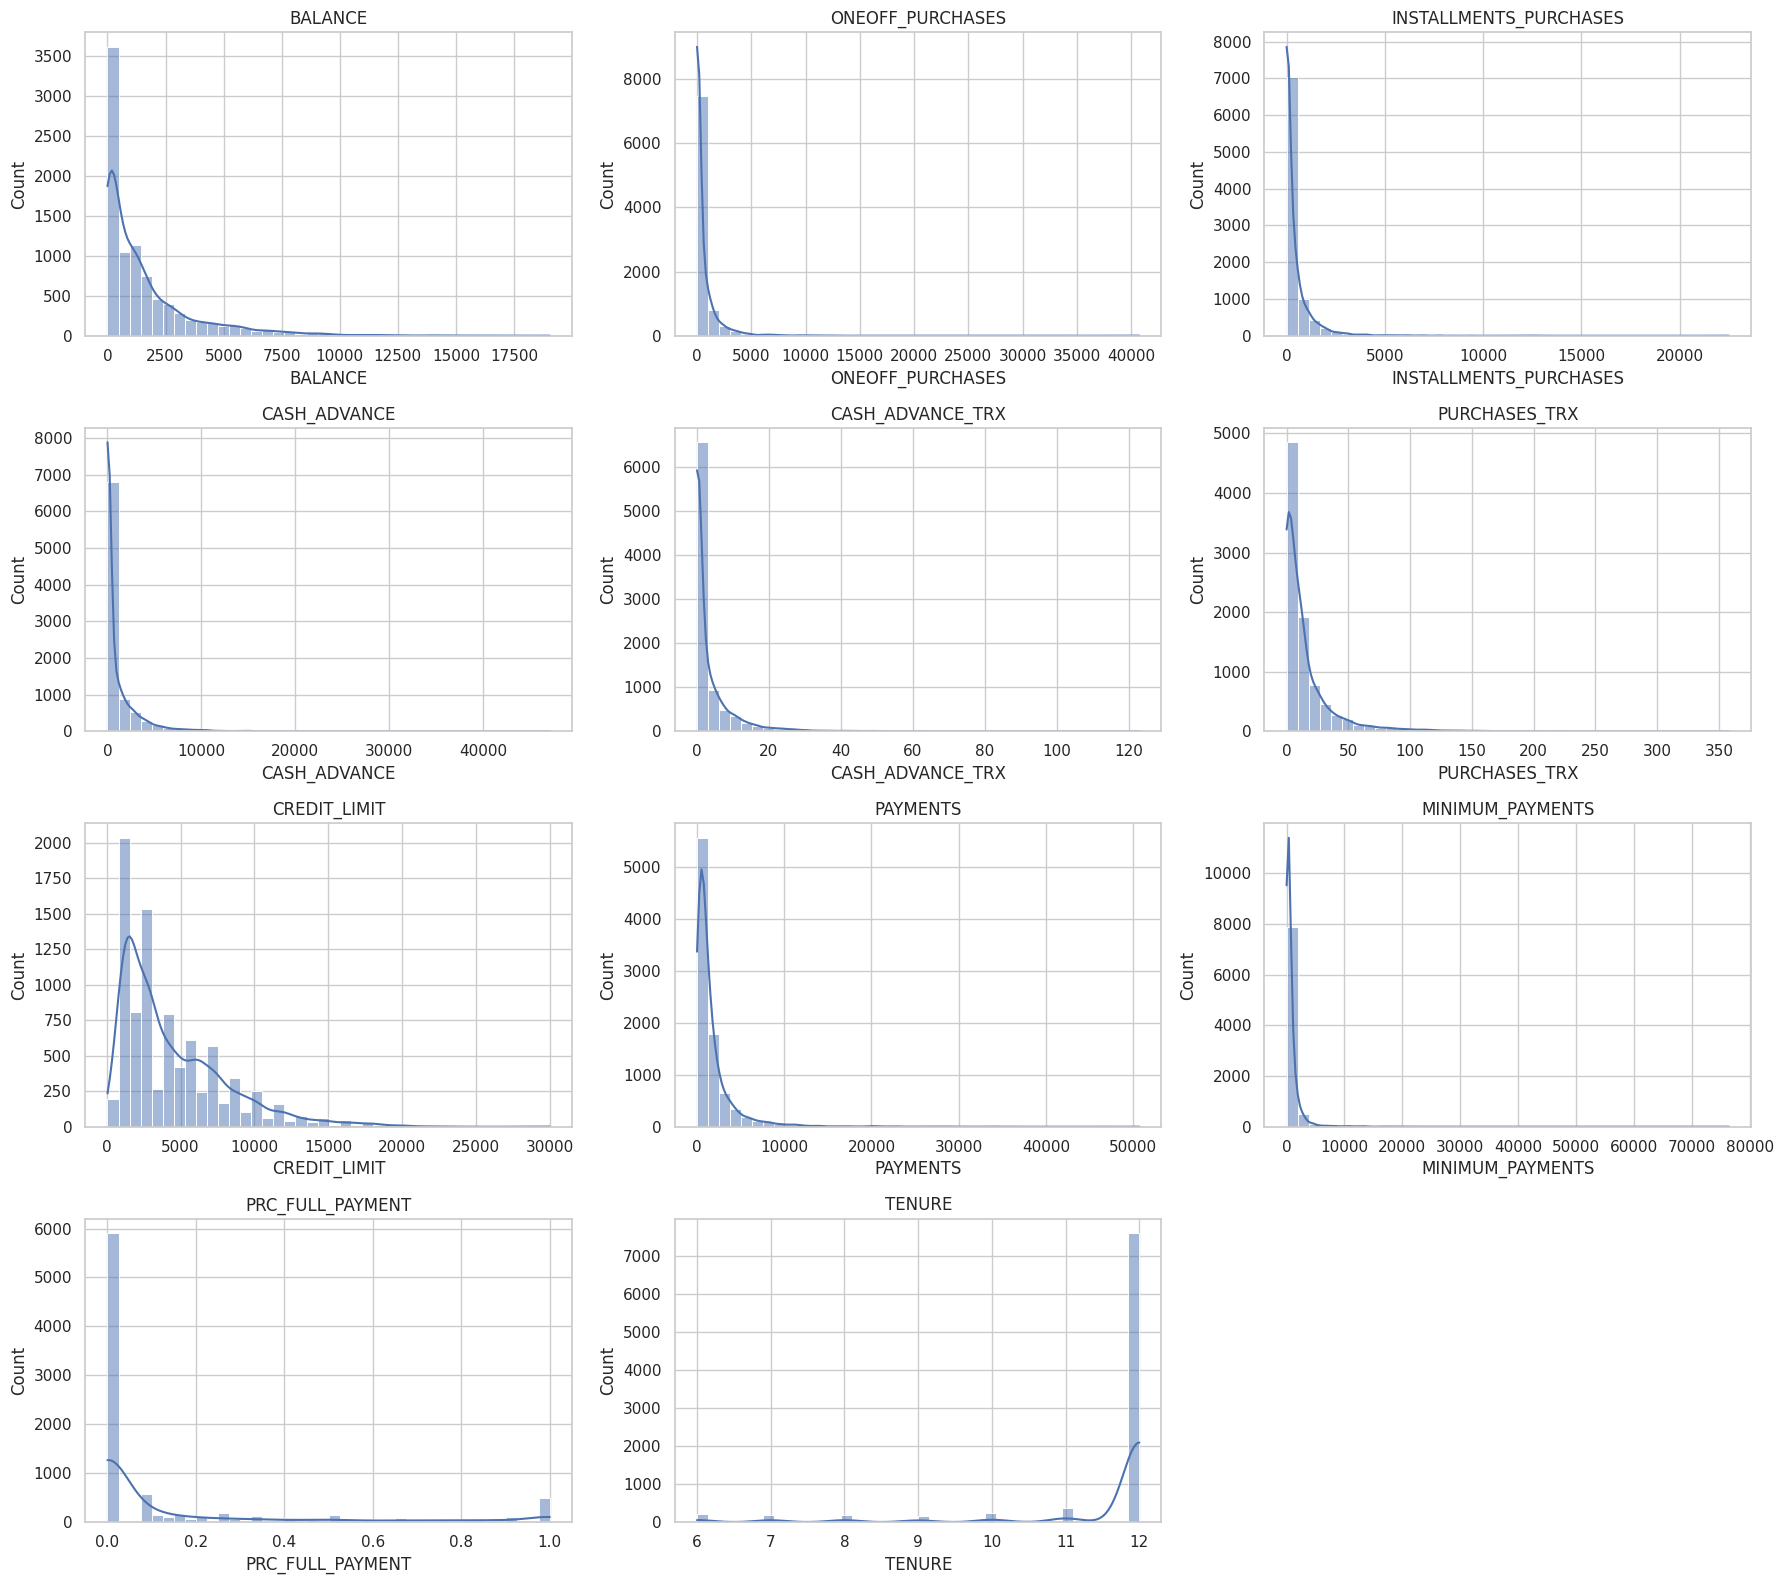

In [9]:
# Distribuicao das variaveis
plot_cols = features
n_cols = 3
n_rows = int(np.ceil(len(plot_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, plot_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)

for ax in axes[len(plot_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

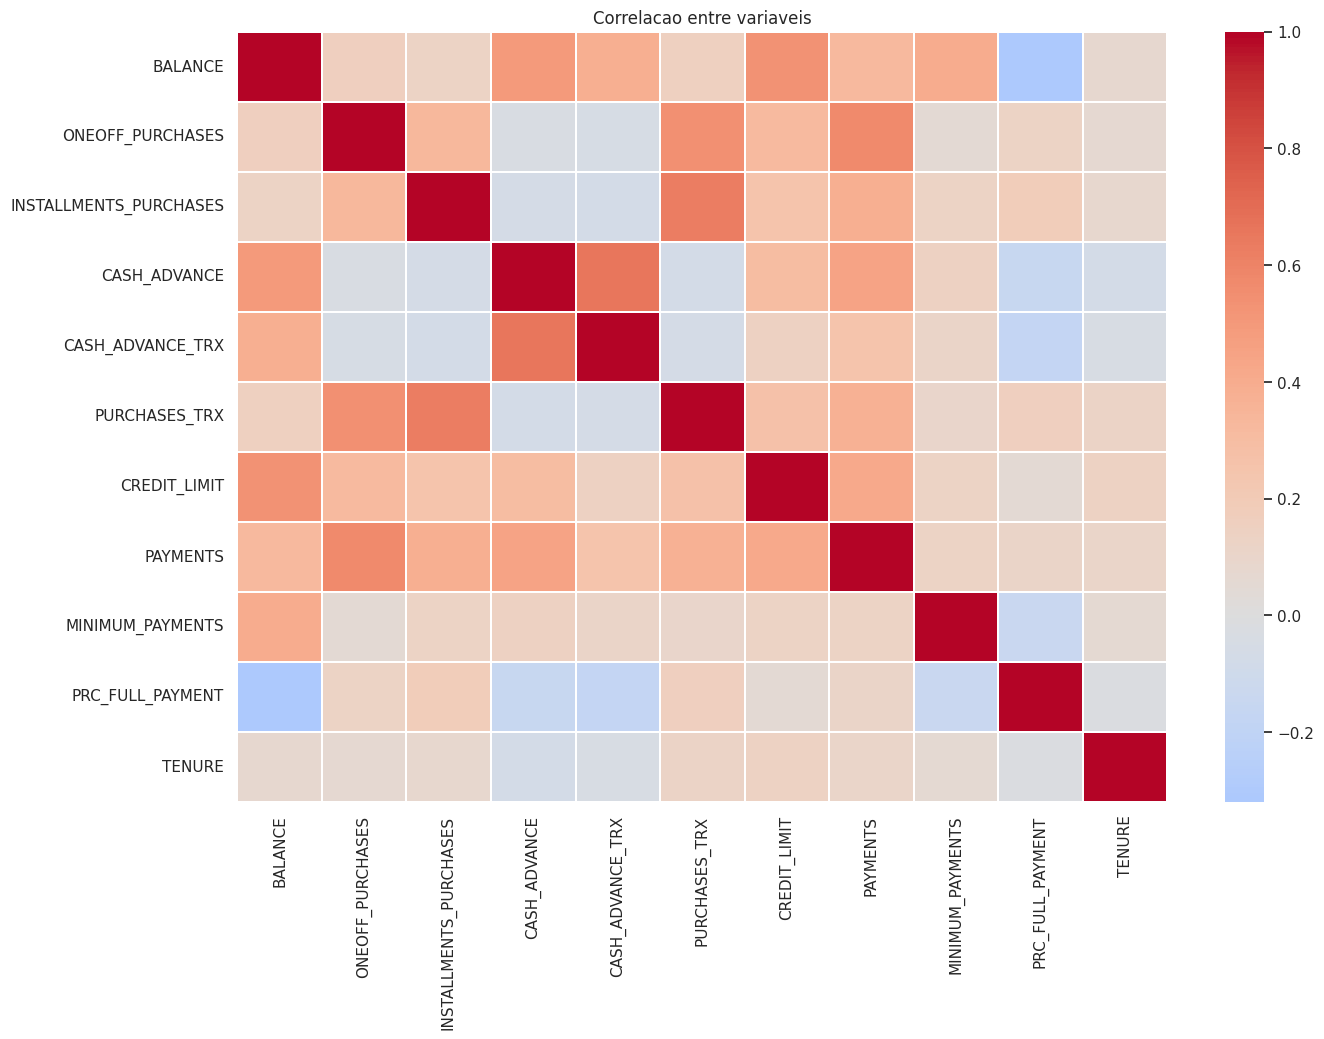

In [10]:
# Matriz de correlacao
corr = df[features].corr(numeric_only=True)

plt.figure(figsize=(15, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Correlacao entre variaveis")
plt.show()

## 3) Preparacao da base para clustering

In [11]:
X_model = df[ features ].dropna().copy()

print( "Shape apos drop:", X_model.shape )
print( "Total de nulos apos drop:", int( X_model.isna().sum().sum() ) )

# Tratamento de assimetria com log1p
skewness = X_model.skew().sort_values( ascending = False )
log_cols = skewness[ skewness.abs() > 1 ].index.tolist()
log_cols = [ c for c in log_cols if ( X_model[ c ] >= 0 ).all() ]

for col in log_cols:
    X_model[ col ] = np.log1p( X_model[ col ] )

print( "Variaveis com log1p aplicado:" )
print( log_cols )

Shape apos drop: (8636, 11)
Total de nulos apos drop: 0
Variaveis com log1p aplicado:
['MINIMUM_PAYMENTS', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'PAYMENTS', 'CASH_ADVANCE_TRX', 'CASH_ADVANCE', 'PURCHASES_TRX', 'BALANCE', 'PRC_FULL_PAYMENT', 'CREDIT_LIMIT', 'TENURE']


In [12]:
# Padronizacao
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_model)

print("Shape final para modelagem:", X_scaled.shape)

Shape final para modelagem: (8636, 11)


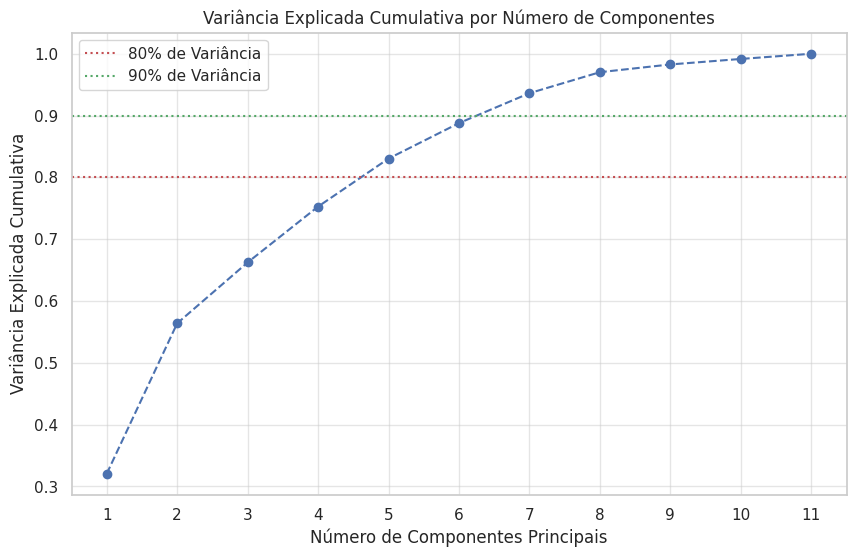

In [30]:
pca_full = PCA()
pca_full.fit(X_scaled)

variancia_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada, marker='o', linestyle='--', color='b')

plt.axhline(y=0.80, color='r', linestyle=':', label='80% de Variância')
plt.axhline(y=0.90, color='g', linestyle=':', label='90% de Variância')

plt.title('Variância Explicada Cumulativa por Número de Componentes')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada Cumulativa')
plt.xticks(range(1, len(variancia_acumulada) + 1))
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()

In [13]:
# PCA para visualizacao
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)
explained_2d = pca_2d.explained_variance_ratio_.sum()

print(f"Variancia explicada por 2 componentes: {explained_2d:.2%}")

Variancia explicada por 2 componentes: 56.39%


## 4) Avaliacao tecnica de k e decisao de negocio

In [14]:
# Avalia k de 2 a 10
k_values = list(range(2, 11))
rows = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=30)
    labels_k = model.fit_predict(X_scaled)

    rows.append({
        "k": k,
        "silhouette": silhouette_score(X_scaled, labels_k),
        "calinski": calinski_harabasz_score(X_scaled, labels_k),
        "davies": davies_bouldin_score(X_scaled, labels_k),
        "inertia": model.inertia_,
    })

k_eval = pd.DataFrame(rows).round(4)
k_eval

,k,silhouette,calinski,davies,inertia
0,2,0.2433,2851.1653,1.6408,71413.4747
1,3,0.2195,2436.7734,1.6002,60718.7663
2,4,0.2036,2121.2614,1.6631,54682.4566
3,5,0.2214,2005.1710,1.4847,49238.9320
4,6,0.2220,1960.8647,1.4406,44472.2620
5,7,0.2007,1850.2221,1.4433,41546.2305
6,8,0.2029,1770.8493,1.4347,38985.3525
7,9,0.2050,1715.1375,1.3934,36671.1732
8,10,0.2054,1652.0991,1.4050,34877.1769


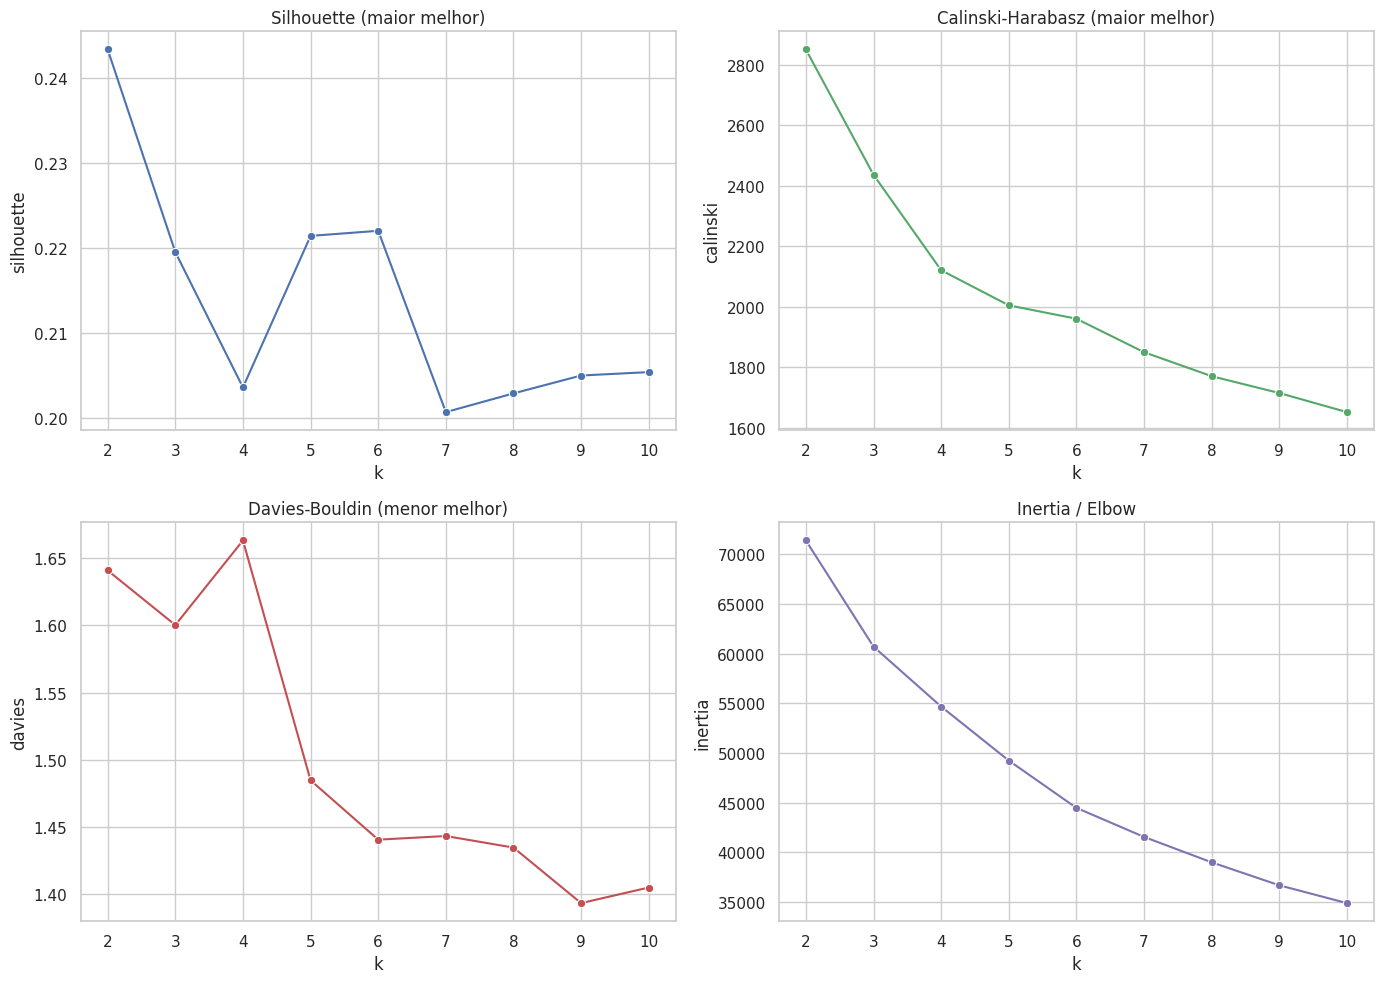

In [15]:
# Curvas de avaliacao
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

sns.lineplot(data=k_eval, x="k", y="silhouette", marker="o", ax=axes[0], color="#4C72B0")
axes[0].set_title("Silhouette (maior melhor)")

sns.lineplot(data=k_eval, x="k", y="calinski", marker="o", ax=axes[1], color="#55A868")
axes[1].set_title("Calinski-Harabasz (maior melhor)")

sns.lineplot(data=k_eval, x="k", y="davies", marker="o", ax=axes[2], color="#C44E52")
axes[2].set_title("Davies-Bouldin (menor melhor)")

sns.lineplot(data=k_eval, x="k", y="inertia", marker="o", ax=axes[3], color="#8172B2")
axes[3].set_title("Inertia / Elbow")

for ax in axes:
    ax.set_xlabel("k")

plt.tight_layout()
plt.show()

## 5) Modelo com 3 clusters

In [ ]:
df = df.dropna()

In [ ]:
# Treino final
kmeans = KMeans(n_clusters = 4, random_state = RANDOM_STATE, n_init = 30)
labels = kmeans.fit_predict( X_scaled )

# Label unico e coeso para todo o notebook
df["cluster"] = labels.astype(int)

global_metrics = pd.DataFrame([
    {
        "k": 4,
        "silhouette": silhouette_score(X_scaled, labels),
        "calinski": calinski_harabasz_score(X_scaled, labels),
        "davies": davies_bouldin_score(X_scaled, labels),
    }
]).round(4)

global_metrics

,k,silhouette,calinski,davies
0,3,0.2195,2436.7734,1.6002


In [33]:
# Silhouette por cliente e por cluster
df["silhouette_sample"] = silhouette_samples(X_scaled, labels)

sil_cluster = (
    df.groupby("cluster")["silhouette_sample"]
    .agg(clientes="count", silhouette_media="mean", silhouette_mediana="median", silhouette_min="min", silhouette_max="max")
    .round(4)
)

sil_cluster

,clientes,silhouette_media,silhouette_mediana,silhouette_min,silhouette_max
cluster,,,,,
0,2838,0.1898,0.1988,-0.0635,0.3998
1,2809,0.1788,0.1676,-0.0257,0.4059
2,2989,0.2859,0.3105,0.0096,0.4888


In [34]:
# Distribuicao dos clusters
cluster_size = df["cluster"].value_counts().sort_index()
cluster_pct = (cluster_size / len(df) * 100).round(2)

cluster_distribution = pd.DataFrame({
    "clientes": cluster_size,
    "percentual": cluster_pct,
})

cluster_distribution

,clientes,percentual
cluster,,
0,2838,32.86
1,2809,32.53
2,2989,34.61


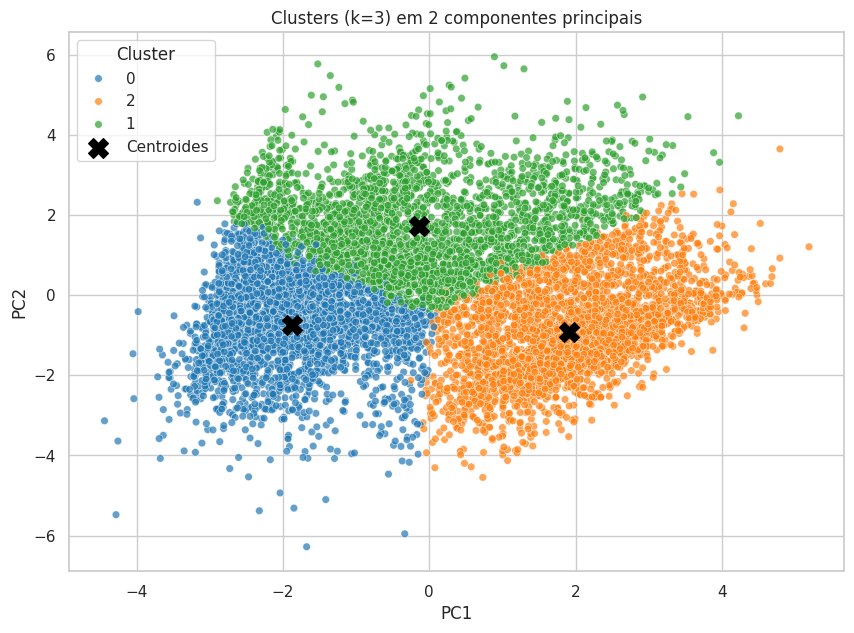

In [ ]:
# Visualizacao dos clusters em PCA
plot_df = pd.DataFrame({
    "pc1": X_pca_2d[:, 0],
    "pc2": X_pca_2d[:, 1],
    "cluster": df["cluster"].astype(str),
})

centroids_pca = pca_2d.transform(kmeans.cluster_centers_)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x="pc1", y="pc2", hue="cluster", palette="tab10", s=30, alpha=0.7)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c="black", marker="X", s=200, label="Centroides")
plt.title("Clusters (k=4) em 2 componentes principais")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

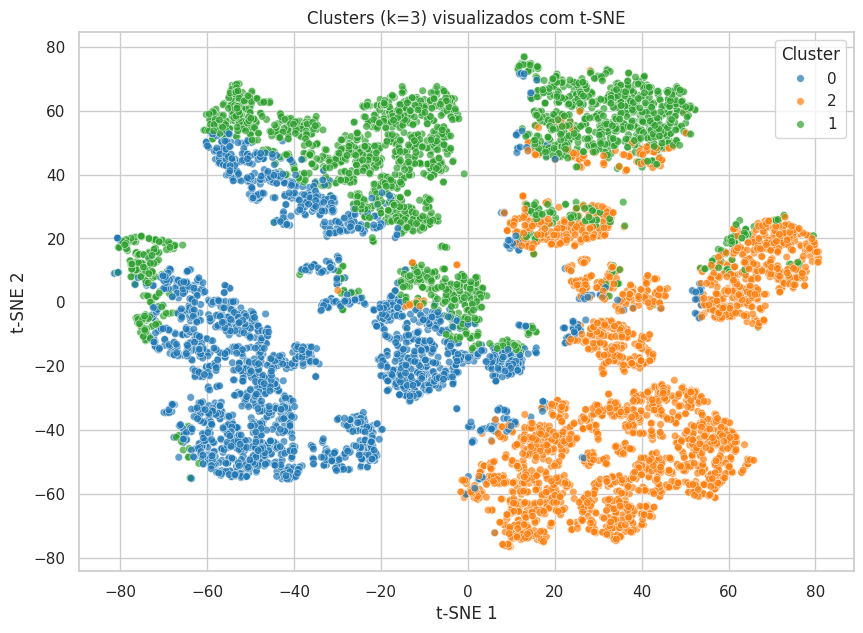

In [ ]:
from sklearn.manifold import TSNE

# Inicializa e roda o t-SNE
# Dica: Se demorar muito, você pode passar os dados já reduzidos 
# por um PCA de 5 componentes (que já bate ~80% de variância) em vez do X_scaled.
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
X_tsne_2d = tsne.fit_transform(X_scaled)

# Cria o DataFrame para o plot
plot_df_tsne = pd.DataFrame({
    "tsne1": X_tsne_2d[:, 0],
    "tsne2": X_tsne_2d[:, 1],
    "cluster": df["cluster"].astype(str),
})

# Visualizacao
plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df_tsne, x="tsne1", y="tsne2", hue="cluster", palette="tab10", s=30, alpha=0.7)
plt.title(f"Clusters (k={4}) visualizados com t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster")
plt.show()

## 6) Modelo com 3 clusters

In [45]:
kmeans = KMeans(n_clusters = K_FINAL, random_state = RANDOM_STATE, n_init = 30)
labels = kmeans.fit_predict( X_scaled )

# Label unico e coeso para todo o notebook
df["cluster"] = labels.astype(int)

global_metrics = pd.DataFrame([
    {
        "k": K_FINAL,
        "silhouette": silhouette_score(X_scaled, labels),
        "calinski": calinski_harabasz_score(X_scaled, labels),
        "davies": davies_bouldin_score(X_scaled, labels),
    }
]).round(4)

global_metrics

,k,silhouette,calinski,davies
0,3,0.2195,2436.7734,1.6002


In [46]:
# Silhouette por cliente e por cluster
df["silhouette_sample"] = silhouette_samples(X_scaled, labels)

sil_cluster = (
    df.groupby("cluster")["silhouette_sample"]
    .agg(clientes="count", silhouette_media="mean", silhouette_mediana="median", silhouette_min="min", silhouette_max="max")
    .round(4)
)

sil_cluster

,clientes,silhouette_media,silhouette_mediana,silhouette_min,silhouette_max
cluster,,,,,
0,2838,0.1898,0.1988,-0.0635,0.3998
1,2809,0.1788,0.1676,-0.0257,0.4059
2,2989,0.2859,0.3105,0.0096,0.4888


In [47]:
# Distribuicao dos clusters
cluster_size = df["cluster"].value_counts().sort_index()
cluster_pct = (cluster_size / len(df) * 100).round(2)

cluster_distribution = pd.DataFrame({
    "clientes": cluster_size,
    "percentual": cluster_pct,
})

cluster_distribution

,clientes,percentual
cluster,,
0,2838,32.86
1,2809,32.53
2,2989,34.61


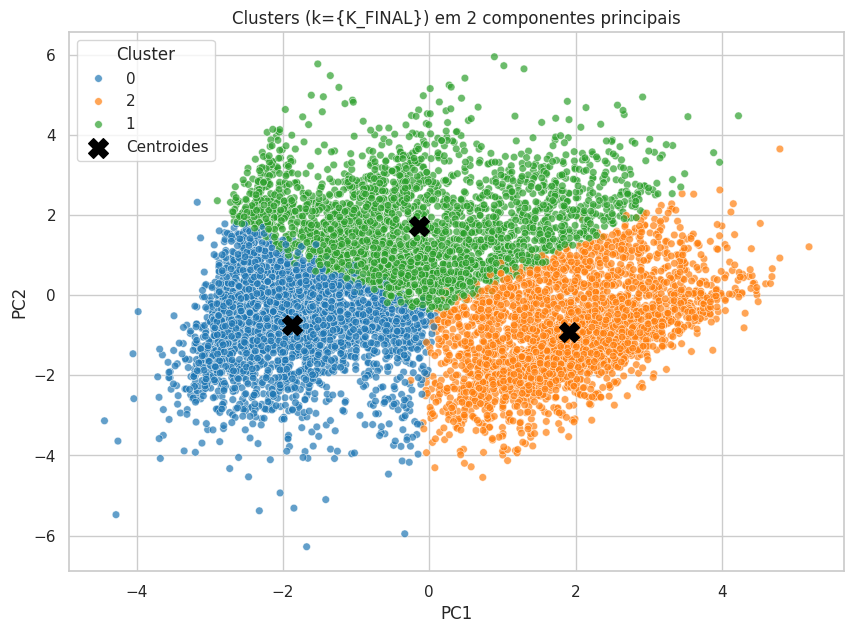

In [48]:
# Visualizacao dos clusters em PCA
plot_df = pd.DataFrame({
    "pc1": X_pca_2d[:, 0],
    "pc2": X_pca_2d[:, 1],
    "cluster": df["cluster"].astype(str),
})

centroids_pca = pca_2d.transform(kmeans.cluster_centers_)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x="pc1", y="pc2", hue="cluster", palette="tab10", s=30, alpha=0.7)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c="black", marker="X", s=200, label="Centroides")
plt.title("Clusters (k={K_FINAL}) em 2 componentes principais")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

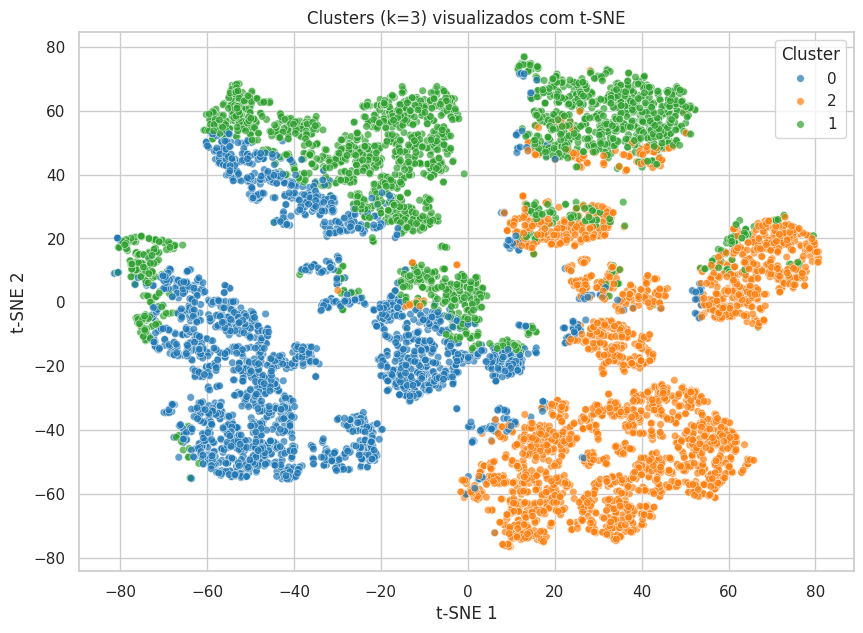

In [50]:
# Inicializa e roda o t-SNE
# Dica: Se demorar muito, você pode passar os dados já reduzidos 
# por um PCA de 5 componentes (que já bate ~80% de variância) em vez do X_scaled.
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
X_tsne_2d = tsne.fit_transform(X_scaled)

# Cria o DataFrame para o plot
plot_df_tsne = pd.DataFrame({
    "tsne1": X_tsne_2d[:, 0],
    "tsne2": X_tsne_2d[:, 1],
    "cluster": df["cluster"].astype(str),
})

# Visualizacao
plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df_tsne, x="tsne1", y="tsne2", hue="cluster", palette="tab10", s=30, alpha=0.7)
plt.title(f"Clusters (k={K_FINAL}) visualizados com t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster")
plt.show()

## 8) Analise aprofundada dos perfis

In [51]:
# Perfil medio, mediano e indice relativo
profile_mean = df.groupby("cluster")[features].mean().round(2)
profile_median = df.groupby("cluster")[features].median().round(2)
profile_index = (profile_mean / df[features].mean()).round(2)

profile_index

,BALANCE,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
cluster,,,,,,,,,,,
0,0.12,0.33,0.76,0.03,0.05,0.67,0.71,0.38,0.22,2.01,0.99
1,1.35,2.56,2.18,0.70,0.68,2.25,1.35,1.64,1.48,0.88,1.03
2,1.50,0.17,0.11,2.20,2.21,0.14,0.94,1.00,1.29,0.19,0.98


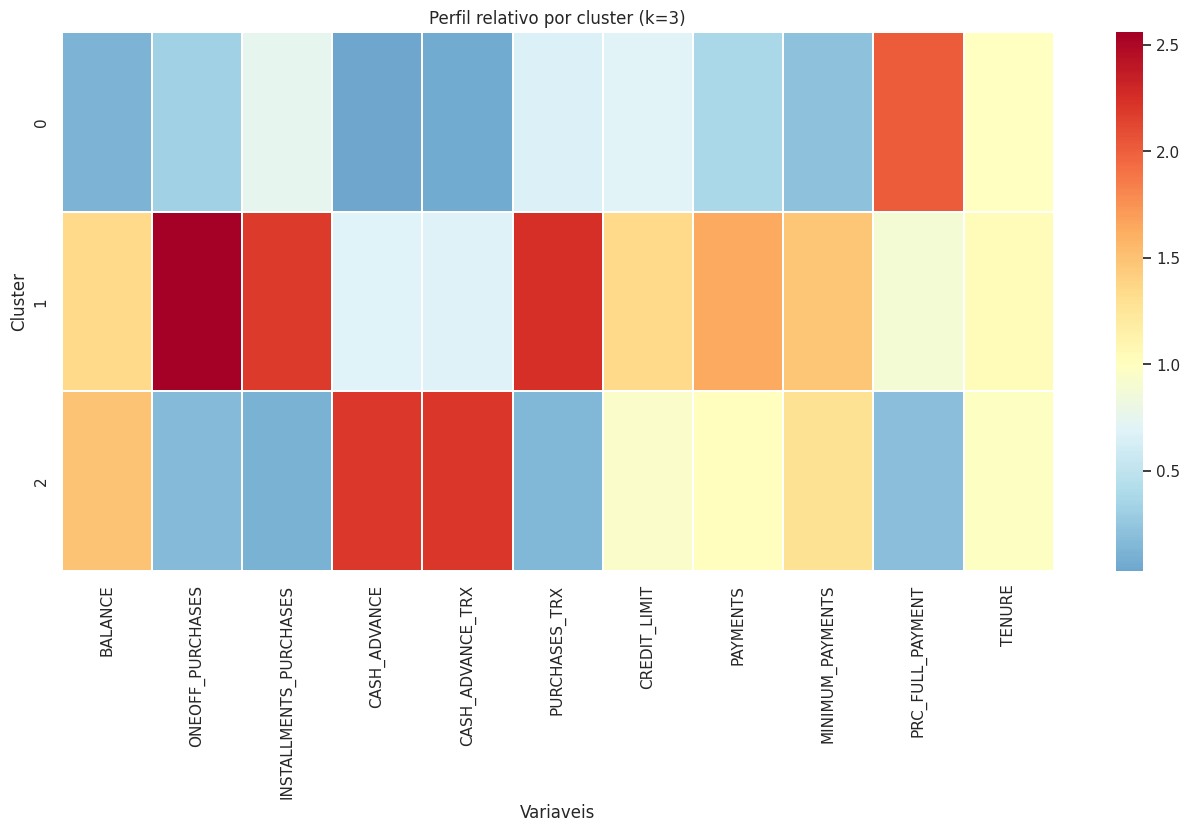

In [52]:
# Heatmap do perfil relativo (1.0 = media da base)
plt.figure(figsize=(16, 7))
sns.heatmap(profile_index, cmap="RdYlBu_r", center=1, linewidths=0.3)
plt.title("Perfil relativo por cluster (k=3)")
plt.xlabel("Variaveis")
plt.ylabel("Cluster")
plt.show()

Cluster 0: Pagador Integral

   - Pico (Vermelho): PRC_FULL_PAYMENT (Percentual de pagamento total).

   - Vales (Azul): BALANCE (Saldo devedor), Compras, Saques.

   - Resumo: É o cliente de baixo risco e baixo engajamento. Usa o cartão de forma moderada ou esporádica, não acumula dívida e tem o hábito de pagar a fatura completa no vencimento.

Cluster 1: Consumidor Intensivo

   - Picos (Vermelho Escuro): ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, PURCHASES_TRX.

   - Vale (Azul Claro): CASH_ADVANCE (Saques).

   - Resumo: É o melhor cliente de varejo. Usa o cartão para tudo, fazendo muitas transações tanto à vista quanto parceladas. Possui limite maior e paga faturas de valor alto, fugindo completamente de saques em dinheiro.

Cluster 2: Tomador de Empréstimo (Alto Risco)

   - Picos (Vermelho): CASH_ADVANCE, CASH_ADVANCE_TRX.

   - Vales (Azul): Compras no geral (ONEOFF e INSTALLMENTS) e PRC_FULL_PAYMENT.

   - Resumo: É o cliente que usa o cartão de crédito como uma linha de empréstimo emergencial. Ele não faz compras no comércio, apenas saca dinheiro, mantém o saldo devedor alto (BALANCE alaranjado) e não consegue pagar a fatura integral. É o grupo que gera mais receita de juros, mas possui o maior risco de inadimplência.

In [53]:
# Poder discriminativo por variavel (eta squared)
def eta_squared(feature_name, cluster_col="cluster"):
    y = df[feature_name]
    grand_mean = y.mean()

    ss_between = 0.0
    for c in sorted(df[cluster_col].unique()):
        y_c = y[df[cluster_col] == c]
        ss_between += len(y_c) * (y_c.mean() - grand_mean) ** 2

    ss_total = ((y - grand_mean) ** 2).sum()
    return float(ss_between / ss_total) if ss_total > 0 else 0.0

eta_rows = []
for f in features:
    eta_rows.append({"feature": f, "eta_squared": eta_squared(f)})

eta_table = pd.DataFrame(eta_rows).sort_values("eta_squared", ascending=False).reset_index(drop=True)
eta_table.head(12)

,feature,eta_squared
0,PURCHASES_TRX,0.284817
1,BALANCE,0.221833
2,CASH_ADVANCE_TRX,0.193025
3,CASH_ADVANCE,0.183914
4,PRC_FULL_PAYMENT,0.160224
5,INSTALLMENTS_PURCHASES,0.157573
6,ONEOFF_PURCHASES,0.151136
7,CREDIT_LIMIT,0.105334
8,PAYMENTS,0.097615
9,MINIMUM_PAYMENTS,0.040337


Eta-squared mede a importância de cada variável na separação dos seus clusters. Ele diz quais colunas foram as verdadeiras responsáveis por dividir os clientes.

Ele varia de 0 a 1. Quanto maior o valor, mais aquela variável ajudou o K-Means a diferenciar os grupos.

In [54]:
# Tabela de spread entre clusters para mostrar diferenca real
spread_table = pd.DataFrame({
    "feature": features,
    "cluster_max": profile_index.idxmax(axis=0).values,
    "cluster_min": profile_index.idxmin(axis=0).values,
    "max_index": profile_index.max(axis=0).values,
    "min_index": profile_index.min(axis=0).values,
})
spread_table["spread_index"] = (spread_table["max_index"] - spread_table["min_index"]).round(2)
spread_table = spread_table.sort_values("spread_index", ascending=False).reset_index(drop=True)

spread_table.head(12)

,feature,cluster_max,cluster_min,max_index,min_index,spread_index
0,ONEOFF_PURCHASES,1,2,2.56,0.17,2.39
1,CASH_ADVANCE,2,0,2.20,0.03,2.17
2,CASH_ADVANCE_TRX,2,0,2.21,0.05,2.16
3,PURCHASES_TRX,1,2,2.25,0.14,2.11
4,INSTALLMENTS_PURCHASES,1,2,2.18,0.11,2.07
5,PRC_FULL_PAYMENT,0,2,2.01,0.19,1.82
6,BALANCE,2,0,1.50,0.12,1.38
7,MINIMUM_PAYMENTS,1,0,1.48,0.22,1.26
8,PAYMENTS,1,0,1.64,0.38,1.26
9,CREDIT_LIMIT,1,0,1.35,0.71,0.64


In [55]:
# Distancia entre centroides (espaco padronizado)
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=features)
arr = centroids.to_numpy()

dist_matrix = np.sqrt(((arr[:, None, :] - arr[None, :, :]) ** 2).sum(axis=2))
centroid_distance_df = pd.DataFrame(
    dist_matrix,
    index=[f"cluster_{i}" for i in range(K_FINAL)],
    columns=[f"cluster_{i}" for i in range(K_FINAL)],
).round(3)

centroid_distance_df

,cluster_0,cluster_1,cluster_2
cluster_0,0.000,3.081,3.808
cluster_1,3.081,0.000,3.406
cluster_2,3.808,3.406,0.000


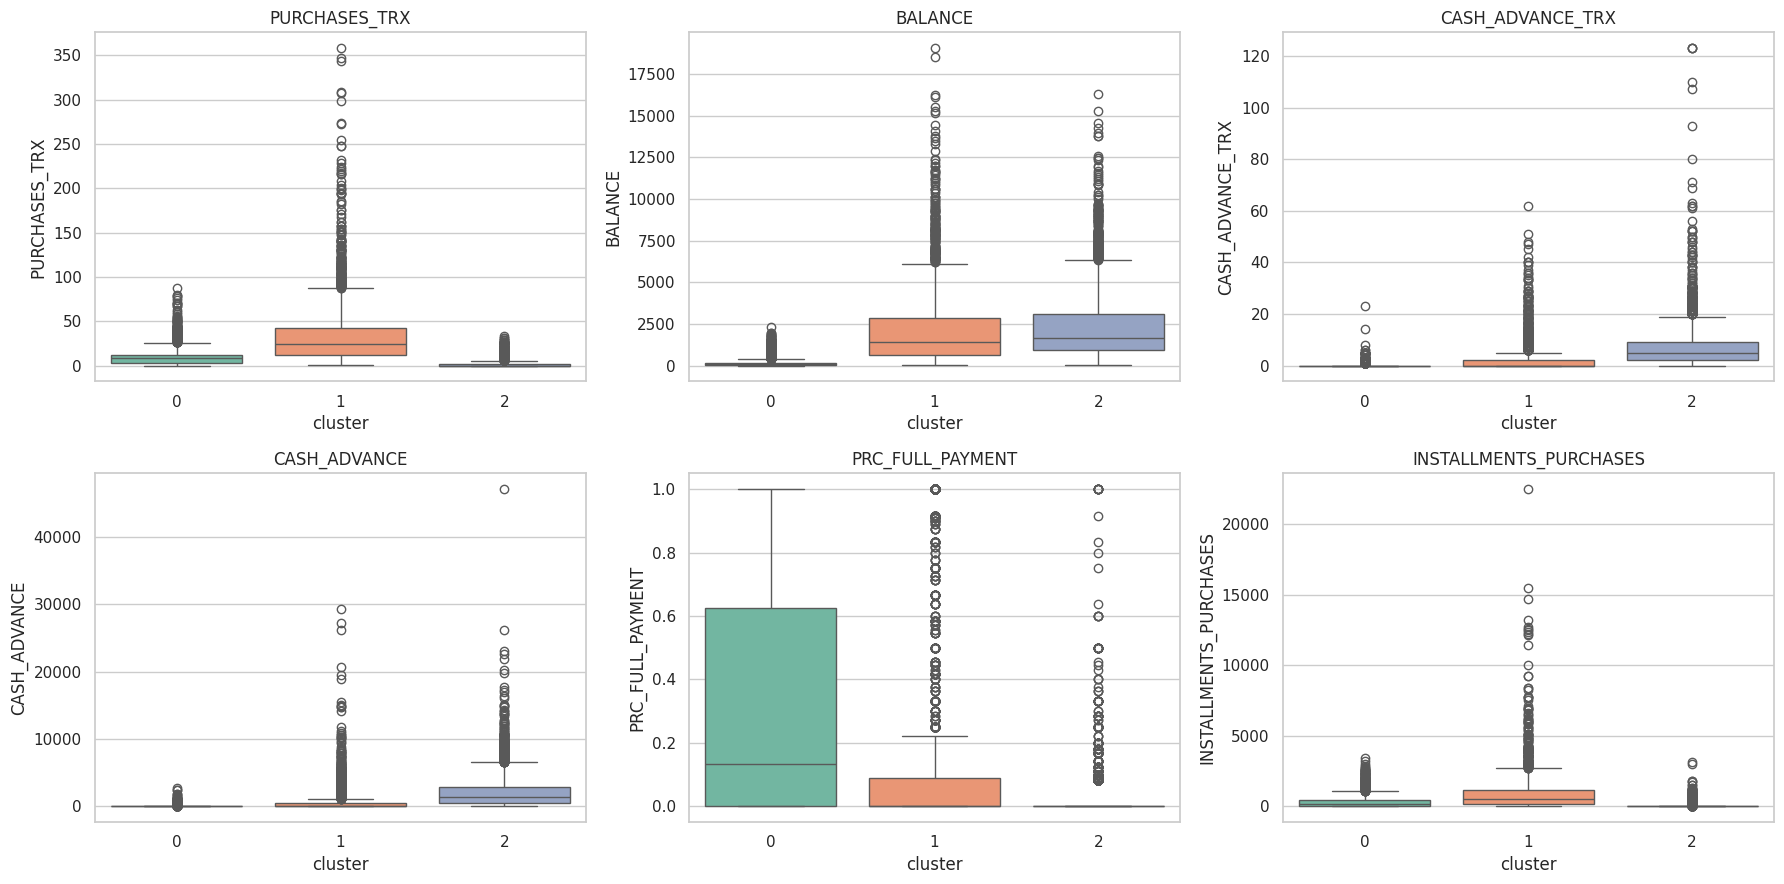

In [56]:
# Boxplots das variaveis mais discriminantes
top_features = eta_table.head(6)["feature"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

for ax, f in zip(axes, top_features):
    sns.boxplot(data=df, x="cluster", y=f, ax=ax, palette="Set2")
    ax.set_title(f)

for ax in axes[len(top_features):]:
    ax.remove()

plt.tight_layout()
plt.show()

In [57]:
# Teste estatistico (Kruskal) nas variaveis mais discriminantes
# Se scipy estiver disponivel, testamos diferenca de distribuicao entre os 3 clusters.
try:
    from scipy.stats import kruskal

    stats_rows = []
    for f in top_features:
        groups = [df.loc[df["cluster"] == c, f].values for c in sorted(df["cluster"].unique())]
        stat, pvalue = kruskal(*groups)
        stats_rows.append({"feature": f, "kruskal_stat": stat, "pvalue": pvalue})

    kruskal_table = pd.DataFrame(stats_rows).sort_values("pvalue")
    kruskal_table
except Exception as e:
    print("scipy nao disponivel no ambiente para executar Kruskal.")
    print("Erro:", e)

In [58]:
kruskal_table

,feature,kruskal_stat,pvalue
0,PURCHASES_TRX,5047.135995,0.000000e+00
1,BALANCE,4608.093765,0.000000e+00
2,CASH_ADVANCE_TRX,5037.604618,0.000000e+00
3,CASH_ADVANCE,4986.463625,0.000000e+00
5,INSTALLMENTS_PURCHASES,3408.363659,0.000000e+00
4,PRC_FULL_PAYMENT,1329.060511,2.501365e-289


## 7) Personas, leitura de negocio e estrategia por perfil

In [61]:
# Regras para nomear personas ajustadas para as colunas atuais
def assign_persona(row):
    # Cluster 2: Usa muito saque e passa pouco o cartão
    if row["CASH_ADVANCE"] >= 1.5 and row["PURCHASES_TRX"] <= 0.8:
        return "Dependentes de Credito Rotativo"
    
    # Cluster 1: Alto volume de transações e gasta muito (à vista ou parcelado)
    if row["PURCHASES_TRX"] >= 1.2 and (row["ONEOFF_PURCHASES"] >= 1.3 or row["INSTALLMENTS_PURCHASES"] >= 1.3):
        return "Compradores Engajados"
    
    # Cluster 0: Paga fatura cheia e quase não usa saque (conservador)
    if row["PRC_FULL_PAYMENT"] >= 1.3 and row["CASH_ADVANCE"] <= 0.9:
        return "Conservadores de Baixo Uso"
    
    return "Perfil Hibrido"


def strategy_by_persona(persona):
    if persona == "Dependentes de Credito Rotativo":
        return "Educacao financeira, monitoramento de risco, ofertas de reorganizacao e limites responsaveis."
    if persona == "Compradores Engajados":
        return "Fidelizacao, cross-sell, beneficios premium, cashback progressivo e campanhas de recorrencia."
    if persona == "Conservadores de Baixo Uso":
        return "Aumentar uso com ofertas simples, gatilhos de frequencia e beneficios por primeira recorrencia."
    return "Estrategia mista com teste A/B e abordagem incremental."


def summarize_drivers(row, high_th=1.15, low_th=0.85, top_n=3):
    high = row[row >= high_th].sort_values(ascending=False).head(top_n)
    low = row[row <= low_th].sort_values().head(top_n)

    if len(high) == 0:
        high_txt = "Sem destaques acima de 1.15x"
    else:
        high_txt = ", ".join([f"{k} ({v:.2f}x)" for k, v in high.items()])

    if len(low) == 0:
        low_txt = "Sem destaques abaixo de 0.85x"
    else:
        low_txt = ", ".join([f"{k} ({v:.2f}x)" for k, v in low.items()])

    return high_txt, low_txt

In [62]:
# Relatorio executivo por cluster
cluster_report = pd.DataFrame({"cluster": sorted(df["cluster"].unique())})
cluster_report["clientes"] = cluster_report["cluster"].map(cluster_size)
cluster_report["percentual"] = cluster_report["cluster"].map(cluster_pct)
cluster_report["silhouette_media"] = cluster_report["cluster"].map(df.groupby("cluster")["silhouette_sample"].mean().round(4))

personas = []
highlights = []
alerts = []
strategies = []

for c in cluster_report["cluster"]:
    row = profile_index.loc[c]
    persona = assign_persona(row)
    high_txt, low_txt = summarize_drivers(row)

    personas.append(persona)
    highlights.append(high_txt)
    alerts.append(low_txt)
    strategies.append(strategy_by_persona(persona))

cluster_report["persona"] = personas
cluster_report["diferenciais_altos"] = highlights
cluster_report["diferenciais_baixos"] = alerts
cluster_report["estrategia_marketing"] = strategies

cluster_report = cluster_report.sort_values("cluster").reset_index(drop=True)
cluster_report

,cluster,clientes,percentual,silhouette_media,persona,diferenciais_altos,diferenciais_baixos,estrategia_marketing
0,0,2838,32.86,0.1898,Conservadores de Baixo Uso,PRC_FULL_PAYMENT (2.01x),"CASH_ADVANCE (0.03x), CASH_ADVANCE_TRX (0.05x)...","Aumentar uso com ofertas simples, gatilhos de ..."
1,1,2809,32.53,0.1788,Compradores Engajados,"ONEOFF_PURCHASES (2.56x), PURCHASES_TRX (2.25x...","CASH_ADVANCE_TRX (0.68x), CASH_ADVANCE (0.70x)","Fidelizacao, cross-sell, beneficios premium, c..."
2,2,2989,34.61,0.2859,Dependentes de Credito Rotativo,"CASH_ADVANCE_TRX (2.21x), CASH_ADVANCE (2.20x)...","INSTALLMENTS_PURCHASES (0.11x), PURCHASES_TRX ...","Educacao financeira, monitoramento de risco, o..."


## 8) Evidencias de diferenciacao entre perfis

In [64]:
# Painel de evidencias objetivas de separacao
sil_global = float(global_metrics.loc[0, "silhouette"])
min_sil_cluster = float(sil_cluster["silhouette_media"].min())

# Menor distancia entre centroides (desconsidera diagonal)
dm = centroid_distance_df.to_numpy().copy()
np.fill_diagonal(dm, np.nan)
min_centroid_distance = float(np.nanmin(dm))

n_features_high_eta = int((eta_table["eta_squared"] >= 0.15).sum())
mean_spread_top10 = float(spread_table.head(10)["spread_index"].mean())

evidence_table = pd.DataFrame([
    {"evidencia": "Silhouette global (k=3)", "valor": round(sil_global, 4)},
    {"evidencia": "Menor silhouette medio entre clusters", "valor": round(min_sil_cluster, 4)},
    {"evidencia": "Menor distancia entre centroides", "valor": round(min_centroid_distance, 3)},
    {"evidencia": "Qtd. variaveis com eta_squared >= 0.15", "valor": n_features_high_eta},
    {"evidencia": "Spread medio das 10 variaveis mais distintas", "valor": round(mean_spread_top10, 2)},
])

evidence_table

,evidencia,valor
0,Silhouette global (k=3),0.2195
1,Menor silhouette medio entre clusters,0.1788
2,Menor distancia entre centroides,3.0810
3,Qtd. variaveis com eta_squared >= 0.15,7.0000
4,Spread medio das 10 variaveis mais distintas,1.7300


In [65]:
# Exportacao final
output_path = "clientes_segmentados_k3.csv"
df.to_csv(output_path, index=False)

print(f"Arquivo salvo: {output_path}")
print("Colunas finais:", list(df.columns))

Arquivo salvo: clientes_segmentados_k3.csv
Colunas finais: ['BALANCE', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE', 'cluster', 'silhouette_sample', 'persona']


## Teste com mistura gaussiana


,Modelo,k,silhouette,calinski,davies
0,GMM,3,0.1876,1654.2405,2.04


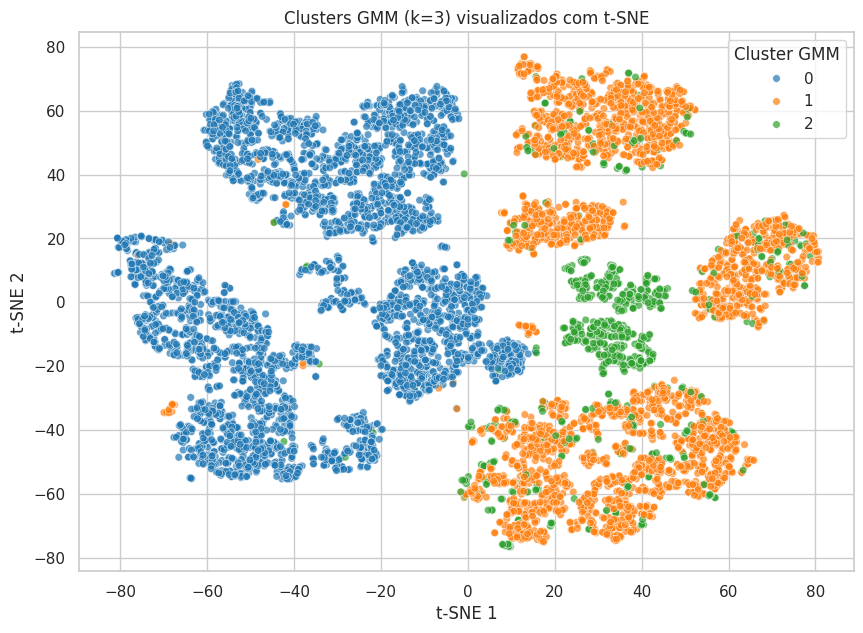

In [69]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# 1. Treino do modelo GMM
gmm = GaussianMixture(n_components=3, random_state=RANDOM_STATE, n_init=30)
labels_gmm = gmm.fit_predict(X_scaled)

# Salva o novo label no dataframe (opcional: criar coluna nova para comparar depois)
df["cluster_gmm"] = labels_gmm.astype(int)

# 2. Cálculo das Métricas Globais
gmm_metrics = pd.DataFrame([
    {
        "Modelo": "GMM",
        "k": 3,
        "silhouette": silhouette_score(X_scaled, labels_gmm),
        "calinski": calinski_harabasz_score(X_scaled, labels_gmm),
        "davies": davies_bouldin_score(X_scaled, labels_gmm),
    }
]).round(4)

display(gmm_metrics)

# 3. Visualização com t-SNE
# Obs: Se você já calculou o tsne antes (X_tsne_2d), não precisa rodar de novo! 
# Pode apenas reaproveitar a variável para economizar tempo computacional.
# Caso não tenha na memória, descomente as duas linhas abaixo:
# tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
# X_tsne_2d = tsne.fit_transform(X_scaled)

plot_df_gmm = pd.DataFrame({
    "tsne1": X_tsne_2d[:, 0],
    "tsne2": X_tsne_2d[:, 1],
    "cluster": df["cluster_gmm"].astype(str),
})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df_gmm, x="tsne1", y="tsne2", hue="cluster", palette="tab10", s=30, alpha=0.7)
plt.title("Clusters GMM (k=3) visualizados com t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster GMM")
plt.show()

não compensa

## Conclusao

Com `k=3` definido por negocio, obtivemos segmentos mais acionaveis e ainda tecnicamente consistentes.

A diferenciacao entre perfis foi demonstrada por:
- metricas de validacao de cluster,
- separacao de centroides,
- poder discriminativo das variaveis,
- spread relativo entre clusters,
- e teste estatistico nas principais variaveis.